# TP Bi-Partite Graph Edit Distance

## 1) Costs Matrices :

We will use the toy problem again to test the implementations of the different functions.

In [44]:
from GED_lib import graph_loader,path_Dijkstra,draw_pair_graph,make_pair_tree,draw_tree,draw_path
import networkx as nx
import numpy as np
%matplotlib inline
import lap
from lap import lapjv
import heapq
import time
import pandas as pd
import itertools
import matplotlib.pyplot as plt

In [24]:
g1_toy = nx.Graph()
g1_toy.add_node(0,node_label = "O")
g1_toy.add_node(1,node_label = "C")
g1_toy.add_node(2,node_label = "O")
g1_toy.add_node(3,node_label = "N")
g1_toy.add_edge(0,1,edge_label = 1)
g1_toy.add_edge(1,2,edge_label = 1)
g1_toy.add_edge(2,3,edge_label = 1)
g1_toy.add_edge(3,1,edge_label = 1)

g2_toy = nx.Graph()
g2_toy.add_node(0,node_label = "N")
g2_toy.add_node(1,node_label = "C")
g2_toy.add_node(2,node_label = "C")
g2_toy.add_edge(0,1,edge_label = 1)
g2_toy.add_edge(1,2,edge_label = 1)

(<Axes: >, <Axes: >)

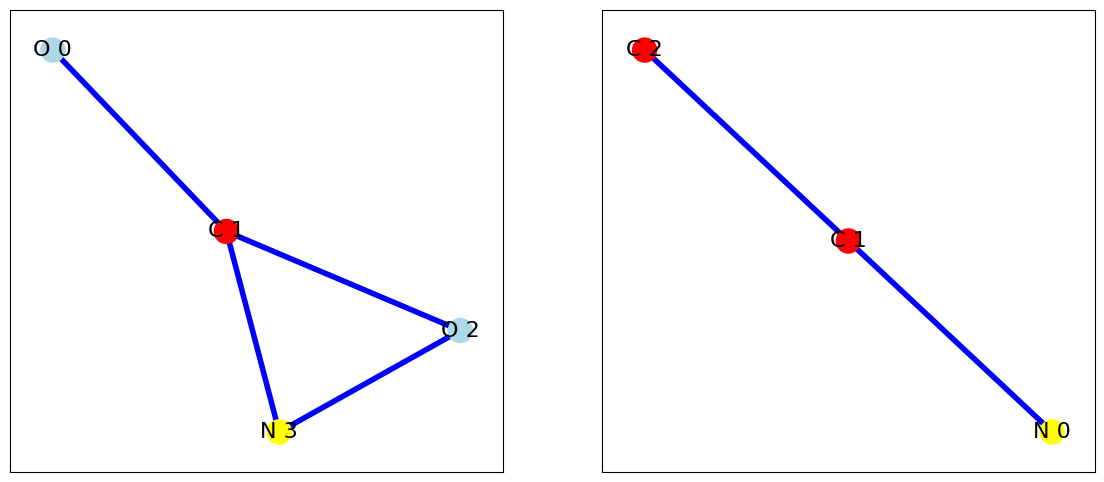

In [25]:
draw_pair_graph(g1_toy,g2_toy)

Here the 3 sets of costs of edits operations are define as follow :

In [26]:
cost1 = {'n_ins':4,'n_sub':2,'n_del':4,'e_ins':1,'e_sub':1,'e_del':1}
cost2 = {'n_ins':4,'n_sub':2,'n_del':4,'e_ins':2,'e_sub':1,'e_del':2}

### a) The C Matrix :

Implement a function that returns the cost matrix $\textbf{C}$ of size (N1+N2,N1+N2), where N1 and N2 are the number of nodes in G1 and G2 respectively.

$$
\textbf{C}_{G_1,G_2}= (c_{i,j}) = \left\{
    \begin{array}{ll}
        cost_{n\_sub(i,j)}  \mbox{ if } i \leq N_1 \mbox{ and } j \leq N_2 \\
        cost_{n\_del(i)}  \mbox{ if } i \leq N_1 \mbox{ and } j = N_2+i \\
        cost_{n\_ins(j)}  \mbox{ if } j \leq N_2 \mbox{ and } i = N_1+j \\
        0 \mbox{ if } i > N_1 \mbox{ and } j > N_2 \\
        \infty \mbox{ otherwise.}
    \end{array}
\right.
$$

An example of output for the toy problem with cost1 (the infinite values are replaced by 100):


    [[  2.,   2.,   2.,   4., 100., 100., 100.],
    [  2.,   0.,   0., 100.,   4., 100., 100.],
    [  2.,   2.,   2., 100., 100.,   4., 100.],
    [  0.,   2.,   2., 100., 100., 100.,   4.],
    [  4., 100., 100.,   0.,   0.,   0.,   0.],
    [100.,   4., 100.,   0.,   0.,   0.,   0.],
    [100., 100.,   4.,   0.,   0.,   0.,   0.]]

In [27]:
def cost_matrix_c(g1, g2, cost):
    N1 = g1.number_of_nodes()
    N2 = g2.number_of_nodes()
    total_size = N1 + N2
    
    c = np.full((total_size, total_size), 100.0)  # 100 as infinity 
 
    #  substitution 
    for i in range(N1):
        for j in range(N2):
            if g1.nodes[i]['node_label'] == g2.nodes[j]['node_label']:
                c[i, j] = 0  # no substitution if labels match
            else:
                c[i, j] = cost['n_sub']  # Substitution if labels differ
    
    # deletion 
    for i in range(N1):
        j = N2 + i
        c[i, j] = cost['n_del']
    
    # insertion 
    for j in range(N2):
        i = N1 + j
        c[i, j] = cost['n_ins']
    
    # zeros for the bottom-right quadrant 
    for i in range(N1, total_size):
        for j in range(N2, total_size):
            c[i, j] = 0.0
    
    return c

In [28]:
c_matrix = cost_matrix_c(g1_toy, g2_toy, cost1)
print("Cost matrix:")
print(c_matrix)

Cost matrix:
[[  2.   2.   2.   4. 100. 100. 100.]
 [  2.   0.   0. 100.   4. 100. 100.]
 [  2.   2.   2. 100. 100.   4. 100.]
 [  0.   2.   2. 100. 100. 100.   4.]
 [  4. 100. 100.   0.   0.   0.   0.]
 [100.   4. 100.   0.   0.   0.   0.]
 [100. 100.   4.   0.   0.   0.   0.]]


### b) The edges cost matrices :

Implement a function which takes as arguments: the pair of graphs G1 and G2, n1 and n2 the node identifiers of the current node match, and cost, the set of matching costs.
The function will return a cost matrix of size (d1+d2,d1+d2), where d1 and d2 are the degrees of nodes n1 and n2 respectively.
$$
\textbf{C_edge}_{(G_1,G_2,n1,n2)}= (c\_edge_{i,j}) = \left\{
    \begin{array}{ll}
        cost_{e\_sub(i,j)}  \mbox{ if } i \leq d_1 \mbox{ and } j \leq d_2 \\
        cost_{e\_del(i)}  \mbox{ if } i \leq d_1 \mbox{ and } j = d_2+i \\
        cost_{e\_ins(j)}  \mbox{ if } j \leq d_2 \mbox{ and } i = d_1+j \\
        0 \mbox{ if } i > d_1 \mbox{ and } j > d_2 \\
        \infty \mbox{ otherwise.}
    \end{array}
\right.
$$

In [29]:
def edge_matrix_cost(g1, g2, n1, n2, cost):
    d1 = g1.degree(n1)
    d2 = g2.degree(n2)
    total_size = d1 + d2
    
    c_edge = np.full((total_size, total_size), 100.0)
    
    edges_n1 = list(g1.edges(n1, data=True))
    edges_n2 = list(g2.edges(n2, data=True))
    
    # substitution 
    for i in range(d1):
        for j in range(d2):
            edge1 = edges_n1[i]
            edge2 = edges_n2[j]
            
            if edge1[2].get('edge_label') == edge2[2].get('edge_label'):
                c_edge[i, j] = 0 
            else:
                c_edge[i, j] = cost['e_sub'] 
    
    # deletion 
    for i in range(d1):
        j = d2 + i
        c_edge[i, j] = cost['e_del']
    
    # insertion 
    for j in range(d2):
        i = d1 + j
        c_edge[i, j] = cost['e_ins']
    
    for i in range(d1, total_size):
        for j in range(d2, total_size):
            c_edge[i, j] = 0.0
    
    return c_edge

In [30]:
c_edge = edge_matrix_cost(g1_toy, g2_toy, 1, 1, cost1)
print(c_edge)

[[  0.   0.   1. 100. 100.]
 [  0.   0. 100.   1. 100.]
 [  0.   0. 100. 100.   1.]
 [  1. 100.   0.   0.   0.]
 [100.   1.   0.   0.   0.]]


### c) The C* matrix :

Now we want to compute a better fitting cost estimation matrix that takes into account both node and edge operation costs.

To do this we will use the Linear Sum Assignment Problem (LSAP) solver.

By introducing a square cost matrix $\textbf{C}$ of size $N$, which describes the cost of a bipartite matching, and a permutation matrix $\textbf{X} = (x_{i,j}) $ also of size $N$, as follows:

$$
    x_{i,j} = \left\{
    \begin{array}{ll}
        1 \text{ if the row i is matched to the column j} \\
        0 \text{ otherwise }
    \end{array}
    \right.
$$

We can define LSAP solution as :
$$
        LSAP_{cost}({\textbf{C}}) = \min_{\textbf{X}} \sum_{i=1}^{N}\sum_{j=1}^{N}c_{i,j}x_{i,j}\\
         s.t. \sum_{i=1}^{N}x_{i,j} = 1 \\     
           \sum_{j=1}^{N}x_{i,j} = 1
$$    
$$   
           x_{i,j} \in \left\{0,1\right\} \forall(i,j) \in [1,...,N] 
$$

With $ LSAP_{cost}({\textbf{C}})$ the minimum cost of the optimal matching performed on $\textbf{C}$.

You can install a library with the LSAP solver : aka Jonker-Volgenant Algorithm, by using the command :

    pip install lap

The implementation comes from : https://github.com/gatagat/lap , you can also find some documentation about the solver on the git.

Implement a function that returns the cost matrix $\textbf{C}^*$ of size (N1+N2,N1+N2) where N1 and N2 are the number of nodes in G1 and G2 respectively.

$$
\textbf{C*}_{G_1,G_2}(i,j)= \left\{
    \begin{array}{ll}
        \textbf{C}_{G_1,G_2}(i,j) + LSAP_{cost}(\textbf{C_edge}_{(G_1,G_2,i,j)}) \mbox{ if } i \leq N_1 \mbox{ and } j \leq N_2 \\
        \textbf{C}_{G_1,G_2}(i,j) + (deg(i) \times cost_{e\_del(i)})  \mbox{ if } i \leq N_1 \mbox{ and } j = N_2+i \\
        \textbf{C}_{G_1,G_2}(i,j) + (deg(j) \times cost_{e\_ins(j)})  \mbox{ if } j \leq N_2 \mbox{ and } i = N_1+j \\
        0 \mbox{ if } i > N_1 \mbox{ and } j > N_2 \\
        \infty \mbox{ otherwise.}
    \end{array}
\right. 
$$

Example of $\textbf{C}^*$ matrix for the toy problem with the cost1 :

    [[  2.,   3.,   2.,   5., 100., 100., 100.],
    [  4.,   1.,   2., 100.,   7., 100., 100.],
    [  3.,   2.,   3., 100., 100.,   6., 100.],
    [  1.,   2.,   3., 100., 100., 100.,   6.],
    [  5., 100., 100.,   0.,   0.,   0.,   0.],
    [100.,   6., 100.,   0.,   0.,   0.,   0.],
    [100., 100.,   5.,   0.,   0.,   0.,   0.]])

In [31]:
def cost_path(g1, g2, path, cost):
    node_cost = 0
    edge_cost = 0

    mapping = {}  # g1_node -> g2_node
    reverse_mapping = {}  # g2_node -> g1_node
    
    for n1, n2 in path:
        if n1 == -1:  # insertion
            node_cost += cost['n_ins']
        elif n2 == -1:  # deletion
            node_cost += cost['n_del']
        else:  # substitution
            if g1.nodes[n1]['node_label'] != g2.nodes[n2]['node_label']:
                node_cost += cost['n_sub']
            mapping[n1] = n2
            reverse_mapping[n2] = n1

    # deletions and substitutions
    for u1, v1 in g1.edges():
        if u1 in mapping and v1 in mapping:
            u2, v2 = mapping[u1], mapping[v1]
            if g2.has_edge(u2, v2):
                # Edge exists in both graphs, check if labels match
                if g1.edges[u1, v1]['edge_label'] != g2.edges[u2, v2]['edge_label']:
                    edge_cost += cost['e_sub']
            else:
                # deletion
                edge_cost += cost['e_del']
        else:
            # edge deletion
            edge_cost += cost['e_del']

    # insertions
    for u2, v2 in g2.edges():
        if u2 in reverse_mapping and v2 in reverse_mapping:
            u1, v1 = reverse_mapping[u2], reverse_mapping[v2]
            if not g1.has_edge(u1, v1):
                # insertion
                edge_cost += cost['e_ins']
        else:
            # insertion
            edge_cost += cost['e_ins']

    return node_cost + edge_cost

In [32]:
def cost_matrix_cstar(g1, g2, cost):
    N1 = g1.number_of_nodes()
    N2 = g2.number_of_nodes()
    total_size = N1 + N2
    
    C_basic = cost_matrix_c(g1, g2, cost)
    
    C_star = np.full((total_size, total_size), 100.0)
    
    # substitutions 
    for i in range(N1):
        for j in range(N2):
            edge_cost_mat = edge_matrix_cost(g1, g2, i, j, cost)
            
            # Solve LSAP for edge matching
            try:
                edge_cost_mat = edge_cost_mat.astype(np.float64)
                cost_val, row_assign, col_assign = lapjv(edge_cost_mat)
                lsap_cost = float(cost_val)
            except Exception as e:
                print(f"Error in LSAP for nodes ({i},{j}): {e}")
                d1 = g1.degree(i)
                d2 = g2.degree(j)
                lsap_cost = min(d1, d2) * cost['e_sub'] + abs(d1 - d2) * cost['e_ins']
            
            C_star[i, j] = C_basic[i, j] + lsap_cost
    
    # deletion
    for i in range(N1):
        j = N2 + i
        degree_i = g1.degree(i)
        C_star[i, j] = C_basic[i, j] + (degree_i * cost['e_del'])
    
    # insertions
    for j in range(N2):
        i = N1 + j
        degree_j = g2.degree(j)
        C_star[i, j] = C_basic[i, j] + (degree_j * cost['e_ins'])
    
    # Zeros for the bottom-right quadrant 
    for i in range(N1, total_size):
        for j in range(N2, total_size):
            C_star[i, j] = 0.0
    
    return C_star

In [33]:
print("Enhanced cost matrix C*:")
C_star = cost_matrix_cstar(g1_toy, g2_toy, cost1)
print(C_star)

Enhanced cost matrix C*:
[[  2.   3.   2.   5. 100. 100. 100.]
 [  4.   1.   2. 100.   7. 100. 100.]
 [  3.   2.   3. 100. 100.   6. 100.]
 [  1.   2.   3. 100. 100. 100.   6.]
 [  5. 100. 100.   0.   0.   0.   0.]
 [100.   6. 100.   0.   0.   0.   0.]
 [100. 100.   5.   0.   0.   0.   0.]]


## 2) Upper Bound :

Now we want to compute an upper bound on the GED from the $\textbf{C}^*$ matrix.

We can do this again using an LSAP solver. As you may have noticed, lapjv() returns the minimum matching cost, but also the indices of the best matching themselves, as follows :

    min_cost,col_ind_bestmatch,raw_ind_bestmatch = lapjv(cost_mat)

You can now copy/paste your cost_path() function from the $\textbf{A}^*$ practical work into the GED_lib library.

Implement a function that takes as input both graphs G1 and G2 and the cost set.

    First compute C* and use lapjv on C*,
    then transform the resulting matching into an edit path,
    then use your cost_path() function on the resulting path.
    Return the path and it's associated cost.


This cost is an upper bound of the GED, why?

Example of output path and UB for the toy problem with cost1 :

    path = [[ 0,  2],[ 1,  1],[ 2, -1],[ 3,  0]]
    UB = 8


In [34]:
def upper_bound(g1,g2,cost):
    C_star = cost_matrix_cstar(g1, g2, cost)
    
    N1 = g1.number_of_nodes()
    N2 = g2.number_of_nodes()
    total_size = N1 + N2
    
    cost_val, col_ind, row_ind = lapjv(C_star)
    
    path = []
    
    for i in range(total_size):
        j = col_ind[i]
        
        if i < N1 and j < N2:
            # substitution
            path.append([i, j])
        elif i < N1 and j >= N2:
            # deletion 
            path.append([i, -1])
        elif i >= N1 and j < N2:
            # insertion 
            path.append([-1, j])
    
    # Remove duplicates 
    current_path_nodes_g1 = set(match[0] for match in path if match[0] != -1)
    current_path_nodes_g2 = set(match[1] for match in path if match[1] != -1)
    
    # Add missing deletions
    for node in range(N1):
        if node not in current_path_nodes_g1:
            path.append([node, -1])
    
    # Add missing insertions  
    for node in range(N2):
        if node not in current_path_nodes_g2:
            path.append([-1, node])
    
    UB = cost_path(g1, g2, path, cost)
    
    return path, UB

In [35]:
path, UB = upper_bound(g1_toy, g2_toy, cost1)
print("Path:", path)
print("Upper bound:", UB)

Path: [[0, 2], [1, 1], [2, -1], [3, 0]]
Upper bound: 8


## 3) Lower Bound :

We will see how to compute a lower bound on the GED. The idea is to underestimate the edge cost matching.
To do this, we will first compute a new matrix cost $\textbf{C}_{LB}$ similar to $\textbf{C}^*$ with a 1/2 factor in the edge cost estimation.

$$
\textbf{C}_{LB}(i,j)= \left\{
    \begin{array}{ll}
        \textbf{C}_{G_1,G_2}(i,j) + LSAP_{cost}(1/2 \times \textbf{C_edge}_{(G_1,G_2,i,j)}) \mbox{ if } i \leq N_1 \mbox{ and } j \leq N_2 \\
        \textbf{C}_{G_1,G_2}(i,j) + (1/2 \times deg(i) \times cost_{e\_del(i)})  \mbox{ if } i \leq N_1 \mbox{ and } j = N_2+i \\
        \textbf{C}_{G_1,G_2}(i,j) + (1/2 \times deg(j) \times cost_{e\_ins(j)})  \mbox{ if } j \leq N_2 \mbox{ and } i = N_1+j \\
        0 \mbox{ if } i > N_1 \mbox{ and } j > N_2 \\
        \infty \mbox{ otherwise.}
    \end{array}
\right. 
$$

Then $LB = LSAP_{cost}(\textbf{C}_{LB})$.

In [36]:
def lower_bound(g1, g2, cost):
    N1 = g1.number_of_nodes()
    N2 = g2.number_of_nodes()
    total_size = N1 + N2
    
    C_basic = cost_matrix_c(g1, g2, cost)
    
    C_LB = np.full((total_size, total_size), 100.0)
    
    # substitutions
    for i in range(N1):
        for j in range(N2):
            edge_cost_mat = edge_matrix_cost(g1, g2, i, j, cost)
            edge_cost_mat_half = edge_cost_mat * 0.5
            
            try:
                cost_val, row_assign, col_assign = lapjv(edge_cost_mat_half.astype(np.float64))
                lsap_cost = float(cost_val)
            except Exception as e:
                d1 = g1.degree(i)
                d2 = g2.degree(j)
                lsap_cost = 0.5 * (min(d1, d2) * cost['e_sub'] + abs(d1 - d2) * cost['e_ins'])
            
            C_LB[i, j] = C_basic[i, j] + lsap_cost
    
    # deletions 
    for i in range(N1):
        j = N2 + i
        degree_i = g1.degree(i)
        C_LB[i, j] = C_basic[i, j] + (0.5 * degree_i * cost['e_del'])
    
    # insertions 
    for j in range(N2):
        i = N1 + j
        degree_j = g2.degree(j)
        C_LB[i, j] = C_basic[i, j] + (0.5 * degree_j * cost['e_ins'])
    
    # bottom-right zeros
    for i in range(N1, total_size):
        for j in range(N2, total_size):
            C_LB[i, j] = 0.0
    
    try:
        min_cost, col_ind, row_ind = lapjv(C_LB.astype(np.float64))
        LB = float(min_cost)
    except Exception as e:
        LB = np.min(C_LB)
    
    return LB

In [37]:
LB = lower_bound(g1_toy, g2_toy, cost1)
print("Lower bound:", LB)

Lower bound: 8.0


## 4) A* with BPGED heuristic :

We can now use the lower bound as a heuristic in the A* function.

Modify your lower bound function, to adapt to nodes that are not already matched in the remaining part to explore (partial matching) and insert it as a heuristic in your A* function.

In [38]:
def lower_bound_path(g1, g2, cost, partial_path):
    matched_g1 = set(n1 for n1, n2 in partial_path if n1 != -1)
    matched_g2 = set(n2 for n1, n2 in partial_path if n2 != -1)
    
    remaining_g1 = set(g1.nodes()) - matched_g1
    remaining_g2 = set(g2.nodes()) - matched_g2
    
    N1 = len(remaining_g1)
    N2 = len(remaining_g2)
    
    if N1 == 0 and N2 == 0:
        return 0
    
    g1_to_g2 = {}
    g2_to_g1 = {}
    for n1, n2 in partial_path:
        if n1 != -1 and n2 != -1:
            g1_to_g2[n1] = n2
            g2_to_g1[n2] = n1
    
    # Calculate cost of already matched nodes
    current_cost = 0
    for n1, n2 in partial_path:
        if n1 == -1:  # Insertion
            current_cost += cost['n_ins']
        elif n2 == -1:  # Deletion
            current_cost += cost['n_del']
        else:  # Substitution
            if g1.nodes[n1]['node_label'] != g2.nodes[n2]['node_label']:
                current_cost += cost['n_sub']
    
    # Calculate cost of already matched edges
    for u1, v1 in g1.edges():
        if u1 in g1_to_g2 and v1 in g1_to_g2:
            u2, v2 = g1_to_g2[u1], g1_to_g2[v1]
            if g2.has_edge(u2, v2):
                if g1.edges[u1, v1]['edge_label'] != g2.edges[u2, v2]['edge_label']:
                    current_cost += cost['e_sub']
            else:
                current_cost += cost['e_del']
        elif u1 in matched_g1 or v1 in matched_g1:
            current_cost += cost['e_del']
    
    for u2, v2 in g2.edges():
        if u2 in g2_to_g1 and v2 in g2_to_g1:
            u1, v1 = g2_to_g1[u2], g2_to_g1[v2]
            if not g1.has_edge(u1, v1):
                current_cost += cost['e_ins']
        elif u2 in matched_g2 or v2 in matched_g2:
            current_cost += cost['e_ins']
    
    # remaining nodes
    sub_g1 = g1.subgraph(remaining_g1).copy()
    sub_g2 = g2.subgraph(remaining_g2).copy()
    
    # Compute lower bound
    if len(remaining_g1) == 0 and len(remaining_g2) == 0:
        return current_cost

    rem_N1 = len(remaining_g1)
    rem_N2 = len(remaining_g2)
    total_rem_size = rem_N1 + rem_N2
    
    # # Map remaining nodes to indices 
    # g1_rem_map = {node: i for i, node in enumerate(remaining_g1)}
    # g2_rem_map = {node: i for i, node in enumerate(remaining_g2)}
    
    C_basic_rem = np.full((total_rem_size, total_rem_size), 100.0)
    
    for i, n1 in enumerate(remaining_g1):
        for j, n2 in enumerate(remaining_g2):
            if g1.nodes[n1]['node_label'] == g2.nodes[n2]['node_label']:
                C_basic_rem[i, j] = 0
            else:
                C_basic_rem[i, j] = cost['n_sub']
    
    # deletion
    for i, n1 in enumerate(remaining_g1):
        j = rem_N2 + i
        degree_i = sub_g1.degree(n1)
        C_basic_rem[i, j] = cost['n_del'] + (0.5 * degree_i * cost['e_del'])
    
    # insertion  
    for j, n2 in enumerate(remaining_g2):
        i = rem_N1 + j
        degree_j = sub_g2.degree(n2)
        C_basic_rem[i, j] = cost['n_ins'] + (0.5 * degree_j * cost['e_ins'])
    
    # Zeros in bottom-right
    for i in range(rem_N1, total_rem_size):
        for j in range(rem_N2, total_rem_size):
            C_basic_rem[i, j] = 0.0
    
    # Add edge substitution costs
    for i, n1 in enumerate(remaining_g1):
        for j, n2 in enumerate(remaining_g2):
            edge_cost_mat = np.zeros((sub_g1.degree(n1) + sub_g2.degree(n2), 
                                    sub_g1.degree(n1) + sub_g2.degree(n2))) + 100.0
            d1 = sub_g1.degree(n1)
            d2 = sub_g2.degree(n2)
            
            min_edges = min(d1, d2)
            edge_diff = abs(d1 - d2)
            edge_lsap_cost = 0.5 * (min_edges * cost['e_sub'] + edge_diff * max(cost['e_ins'], cost['e_del']))
            
            C_basic_rem[i, j] += edge_lsap_cost
    
    # Solve LSAP for remaining nodes
    try:
        min_cost_rem, _, _ = lap.lapjv(C_basic_rem.astype(np.float64))
        remaining_cost = float(min_cost_rem)
    except:
        # Fallback
        remaining_cost = np.sum([cost['n_del'] for _ in remaining_g1]) + np.sum([cost['n_ins'] for _ in remaining_g2])
    
    return current_cost + remaining_cost

In [39]:
def A_star_BPGED(g1, g2, cost):
    open_set = []

    start_path = []
    g_cost = 0
    h_cost = lower_bound_path(g1, g2, cost, start_path)
    f_cost = g_cost + h_cost
    
    heapq.heappush(open_set, (f_cost, g_cost, start_path))
    visited = set()
    
    while open_set:
        f_current, g_current, current_path = heapq.heappop(open_set)
        
        path_hash = tuple(sorted((n1, n2) for n1, n2 in current_path))
        
        if path_hash in visited:
            continue
            
        visited.add(path_hash)
        
        matched_g1 = set(n1 for n1, n2 in current_path if n1 != -1)
        matched_g2 = set(n2 for n1, n2 in current_path if n2 != -1)
        
        if len(matched_g1) == len(g1.nodes()) and len(matched_g2) == len(g2.nodes()):
            ged = g_current
            return ged, current_path
        
        remaining_g1 = set(g1.nodes()) - matched_g1
        remaining_g2 = set(g2.nodes()) - matched_g2
        
        if remaining_g1:
            next_g1 = min(remaining_g1)  
            
            for next_g2 in remaining_g2:
                new_path = current_path + [(next_g1, next_g2)]

                new_g_cost = cost_path(g1, g2, new_path, cost)
                new_h_cost = lower_bound_path(g1, g2, cost, new_path)
                new_f_cost = new_g_cost + new_h_cost
                
                heapq.heappush(open_set, (new_f_cost, new_g_cost, new_path))
            
            new_path = current_path + [(next_g1, -1)]
            new_g_cost = cost_path(g1, g2, new_path, cost)
            new_h_cost = lower_bound_path(g1, g2, cost, new_path)
            new_f_cost = new_g_cost + new_h_cost
            
            heapq.heappush(open_set, (new_f_cost, new_g_cost, new_path))
            
        else:
            for next_g2 in remaining_g2:
                new_path = current_path + [(-1, next_g2)]
                new_g_cost = cost_path(g1, g2, new_path, cost)
                new_h_cost = lower_bound_path(g1, g2, cost, new_path)
                new_f_cost = new_g_cost + new_h_cost
                
                heapq.heappush(open_set, (new_f_cost, new_g_cost, new_path))
    
    return float('inf'), []



In [40]:
print("A* algorithm:")
ged, path = A_star_BPGED(g1_toy, g2_toy, cost1)
print("GED:", ged)
print("Path:", path)

A* algorithm:
GED: 10
Path: [(0, 2), (1, 1), (2, 0), (3, -1)]


## 5) Experiments :

Now that your tools are ready, you should fill a data frame with the pairs of the 6 graphs in the database.

For each pair, compute the upper bound, the lower bound and the GED of the pairs with BPGED and your A* with the heuristic for cost2.

Verify that LB and UB are a lower and upper bounds of the GED by plotting them on a figure.

Show how fast your A* algorithm has improved with the heuristic.

In [41]:
def cost_path_tp_Astar(g1, g2, path, cost):
    node_cost = 0
    edge_cost = 0

    mapping = {}  # g1_node -> g2_node
    for n1, n2 in path:
        if n1 is None:
            node_cost += cost['n_ins']
        elif n2 is None:
            node_cost += cost['n_del']
        else:
            node_cost += cost['n_sub'] if g1.nodes[n1] != g2.nodes[n2] else 0
            mapping[n1] = n2

    # Handle edges
    for (u1, v1) in g1.edges:
        if u1 in mapping and v1 in mapping:
            u2, v2 = mapping[u1], mapping[v1]
            if g2.has_edge(u2, v2):
                edge_cost += cost['e_sub'] if g1.edges[u1, v1] != g2.edges[u2, v2] else 0
            else:
                edge_cost += cost['e_del']
        elif u1 in mapping or v1 in mapping:
            edge_cost += cost['e_del']

    for (u2, v2) in g2.edges:
        g1_u = [k for k, v in mapping.items() if v == u2]
        g1_v = [k for k, v in mapping.items() if v == v2]
        if not g1_u or not g1_v or not g1.has_edge(g1_u[0], g1_v[0]):
            edge_cost += cost['e_ins']

    return node_cost + edge_cost

def is_complete(g1, g2, path):
    g1_nodes = set(g1.nodes)
    g2_nodes = set(g2.nodes)

    mapped_g1 = set()
    mapped_g2 = set()

    for n1, n2 in path:
        if n1 is not None:
            mapped_g1.add(n1)
        if n2 is not None:
            mapped_g2.add(n2)

    return mapped_g1 == g1_nodes and mapped_g2 == g2_nodes

def A_star(g1, g2, cost):
    g1_nodes = list(g1.nodes)
    g2_nodes = list(g2.nodes)

    initial_path = []
    open_set = []
    counter = itertools.count()  # tie-breaker

    heapq.heappush(open_set, (0, next(counter), initial_path))

    best_path = None
    best_cost = float('inf')

    while open_set:
        curr_cost, _, path = heapq.heappop(open_set)

        if is_complete(g1, g2, path):
            if curr_cost < best_cost:
                best_cost = curr_cost
                best_path = path
            continue

        # Get unmapped nodes
        mapped_g1 = {n1 for n1, _ in path if n1 is not None}
        mapped_g2 = {n2 for _, n2 in path if n2 is not None}

        unmapped_g1 = [n for n in g1_nodes if n not in mapped_g1]
        unmapped_g2 = [n for n in g2_nodes if n not in mapped_g2]

        # Generate successors
        if unmapped_g1 and unmapped_g2:
            n1 = unmapped_g1[0]
            for n2 in unmapped_g2:
                new_path = path + [(n1, n2)]
                total_cost = cost_path_tp_Astar(g1, g2, new_path, cost)
                heapq.heappush(open_set, (total_cost, next(counter), new_path))

        if unmapped_g1:
            n1 = unmapped_g1[0]
            new_path = path + [(n1, None)]
            total_cost = cost_path_tp_Astar(g1, g2, new_path, cost)
            heapq.heappush(open_set, (total_cost, next(counter), new_path))

        if unmapped_g2:
            n2 = unmapped_g2[0]
            new_path = path + [(None, n2)]
            total_cost = cost_path_tp_Astar(g1, g2, new_path, cost)
            heapq.heappush(open_set, (total_cost, next(counter), new_path))

    return best_cost, best_path

In [42]:
path = './data'
data = graph_loader(path)
data

{'g0': <networkx.classes.graph.Graph at 0x27e4e462960>,
 'g1': <networkx.classes.graph.Graph at 0x27e74894fb0>,
 'g2': <networkx.classes.graph.Graph at 0x27e748b14c0>,
 'g3': <networkx.classes.graph.Graph at 0x27e748b1100>,
 'g4': <networkx.classes.graph.Graph at 0x27e748b1700>,
 'g5': <networkx.classes.graph.Graph at 0x27e748b0920>}

In [50]:
graph_names = list(data.keys())
results = []

print("Computing GED, bounds, and performance metrics for all graph pairs...")

for i, g1_name in enumerate(graph_names):
    for j, g2_name in enumerate(graph_names):
        if i < j:  # Avoid duplicate pairs (since GED is symmetric)
            g1 = data[g1_name]
            g2 = data[g2_name]
            
            print(f"Processing pair: {g1_name} vs {g2_name}")
            
            # Compute Lower Bound
            start_time = time.time()
            LB = lower_bound(g1, g2, cost2)
            lb_time = time.time() - start_time
            
            # Compute Upper Bound  
            start_time = time.time()
            ub_path, UB = upper_bound(g1, g2, cost2)
            ub_time = time.time() - start_time
            
            # Compute Exact GED with A* (with heuristic)
            start_time = time.time()
            ged_astar_heuristic, path_astar_heuristic = A_star_BPGED(g1, g2, cost2)
            astar_heuristic_time = time.time() - start_time
            
            # For comparison: Compute A* without heuristic (using 0 heuristic)
            def zero_heuristic(g1, g2, cost, path):
                return 0
            
            start_time = time.time()
            ged_astar_no_heuristic, path_astar_no_heuristic = A_star(g1, g2, cost2)
            astar_no_heuristic_time = time.time() - start_time
            
            # Store results
            results.append({
                'Graph1': g1_name,
                'Graph2': g2_name,
                'LB': LB,
                'UB': UB,
                'GED_Astar_Heuristic': ged_astar_heuristic,
                'GED_Astar_No_Heuristic': ged_astar_no_heuristic,
                'LB_Time': lb_time,
                'UB_Time': ub_time,
                'Astar_Heuristic_Time': astar_heuristic_time,
                'Astar_No_Heuristic_Time': astar_no_heuristic_time,
                'Nodes_G1': g1.number_of_nodes(),
                'Nodes_G2': g2.number_of_nodes(),
                'Edges_G1': g1.number_of_edges(),
                'Edges_G2': g2.number_of_edges()
            })

# Create DataFrame
df = pd.DataFrame(results)
print("\nResults DataFrame:")
print(df)

# Verify bounds
print("\nVerifying bounds:")
df['LB_Valid'] = df['LB'] <= df['GED_Astar_Heuristic']
df['UB_Valid'] = df['UB'] >= df['GED_Astar_Heuristic']
print(f"Lower bounds valid: {df['LB_Valid'].all()}")
print(f"Upper bounds valid: {df['UB_Valid'].all()}")


Computing GED, bounds, and performance metrics for all graph pairs...
Processing pair: g0 vs g1
Processing pair: g0 vs g2
Processing pair: g0 vs g3
Processing pair: g0 vs g4
Processing pair: g0 vs g5
Processing pair: g1 vs g2
Processing pair: g1 vs g3
Processing pair: g1 vs g4
Processing pair: g1 vs g5
Processing pair: g2 vs g3
Processing pair: g2 vs g4
Processing pair: g2 vs g5
Processing pair: g3 vs g4
Processing pair: g3 vs g5
Processing pair: g4 vs g5

Results DataFrame:
   Graph1 Graph2    LB  UB  GED_Astar_Heuristic  GED_Astar_No_Heuristic  \
0      g0     g1  14.0  18                   18                      16   
1      g0     g2   8.5  16                   16                      12   
2      g0     g3   3.5  10                   10                       5   
3      g0     g4  10.0  16                   15                      12   
4      g0     g5  11.0  20                   15                      11   
5      g1     g2   9.5  26                   19                      1

([<matplotlib.axis.XTick at 0x27e0772cce0>,
 [Text(0, 0, 'g0-g1'),
  Text(1, 0, 'g0-g2'),
  Text(2, 0, 'g0-g3'),
  Text(3, 0, 'g0-g4'),
  Text(4, 0, 'g0-g5'),
  Text(5, 0, 'g1-g2'),
  Text(6, 0, 'g1-g3'),
  Text(7, 0, 'g1-g4'),
  Text(8, 0, 'g1-g5'),
  Text(9, 0, 'g2-g3'),
  Text(10, 0, 'g2-g4'),
  Text(11, 0, 'g2-g5'),
  Text(12, 0, 'g3-g4'),
  Text(13, 0, 'g3-g5'),
  Text(14, 0, 'g4-g5')])

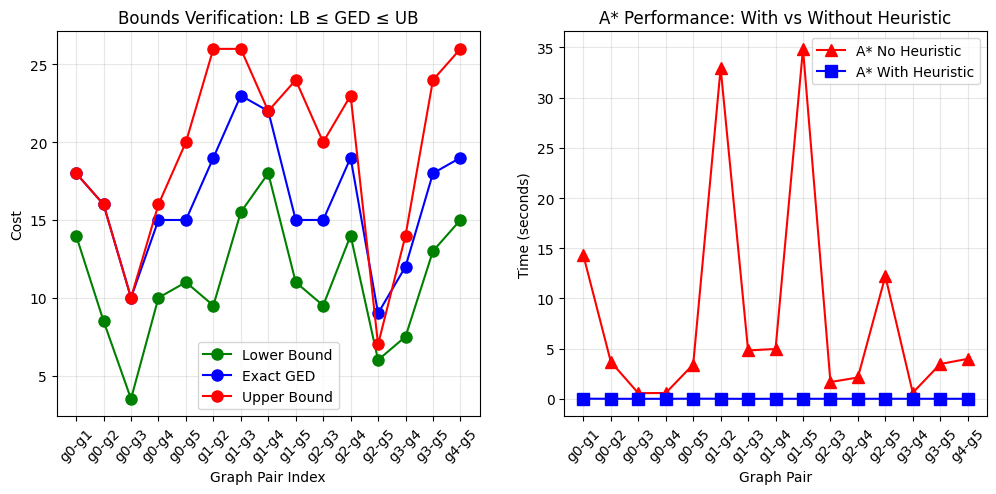

In [51]:
# Plot bounds vs GED
plt.figure(figsize=(12, 5))

# Plot 1: Bounds verification
plt.subplot(1, 2, 1)
x_pos = range(len(df))
plt.plot(x_pos, df['LB'], 'go-', label='Lower Bound', markersize=8)
plt.plot(x_pos, df['GED_Astar_Heuristic'], 'bo-', label='Exact GED', markersize=8)
plt.plot(x_pos, df['UB'], 'ro-', label='Upper Bound', markersize=8)
plt.xlabel('Graph Pair Index')
plt.ylabel('Cost')
plt.title('Bounds Verification: LB ≤ GED ≤ UB')
plt.legend()
plt.grid(True, alpha=0.3)

# Add pair labels
pair_labels = [f"{row['Graph1']}-{row['Graph2']}" for _, row in df.iterrows()]
plt.xticks(x_pos, pair_labels, rotation=45)

# Plot 2: Performance comparison (time)
plt.subplot(1, 2, 2)
plt.plot(x_pos, df['Astar_No_Heuristic_Time'], 'r^-', label='A* No Heuristic', markersize=8)
plt.plot(x_pos, df['Astar_Heuristic_Time'], 'bs-', label='A* With Heuristic', markersize=8)
plt.xlabel('Graph Pair')
plt.ylabel('Time (seconds)')
plt.title('A* Performance: With vs Without Heuristic')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(x_pos, pair_labels, rotation=45)

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
  We can see that defining the lowerbound greatly contributes to the algorithm's efficiency. The method with heuristic has a considerably shorter execution time than the method without heuristic. This effect is even more pronounced in cases like g1-g2 and g1-g5, where the A-star exploration tree is highly branched and the method without heuristic had to perform all the exploration, while the method with heuristic could cut unnecessary branches.
  </p>
</div>